# Manning's coefficient map 
This script creates a raster file of manning coefficients for a watershed of interest. 
Manning's coefficient are assigned independently for main channel areas of the river system and the rest of the watershed.
First, the land cover dataset NLCD is used to translate land use classess to manning's coefficient using the
recommended values from HEC-RAS 2D. Second, Manning's coefficient for the main channel areas of the river system is computed as follow:
A polygon shapefile representing the main channel areas is calculated using a buffer of the NHDPlusV2 centerlines with river widths calculated from McManamay et al., 2019. 
Next, the manning's coefficient for each reach is assigned either as a (A) contant value for all the river channel areas, (B) Based on the Horton-Strahler stream order similar than WRF-hydro,and 
(C) based on the USGS product E2NHDPlusV2 or nhd-roughness Johnson, J.M et al., 2021. 

Note that the mannings values from the USGS product E2NHDPlusV2 or nhd-roughness Johnson, J.M et al., 2021. are the same, then we use as the reference the USGS source.
* Future implementations should replace the estimations from Johnson 2021 since those show very high manning coefficients

Ideally, future implementation should be focused on using manning's coefficient from local hydraulic studies. 

# Links:
1. NHDPlusV2: https://www.epa.gov/waterdata/get-nhdplus-national-hydrography-dataset-plus-data
2. River widths (table with COMID) from McManamay et al., 2019 (https://www.nature.com/articles/sdata201917)
3. Manning coefficients (table with COMID) from the USGS (https://www.sciencebase.gov/catalog/item/63cb311ed34e06fef14f40a3) or nhd-roughness: https://www.hydroshare.org/resource/6092c8a62fac45be97a09bfd0b0bf726/ 
4. From NLCD classes to manning's coefficient: https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/developing-a-terrain-model-and-geospatial-layers/creating-land-cover-mannings-n-values-and-impervious-layers
5. Straler stream order to mannings'coefficient : https://ral.ucar.edu/sites/default/files/public/images/project/WRF_Hydro_User_Guide_v3.0.pdf 


In [1]:

# Load libraries
import rasterio
import pandas as pd
import geopandas as gpd
# import requests
import os
from rasterio.mask import mask
from rasterio.warp import transform_bounds
from rasterio.features import rasterize
from rasterio.enums import Resampling
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import pyproj
# %matplotlib inline
import numpy as np
import watershed_workflow 
import watershed_workflow.source_list
# import ipympl

from shapely.geometry import box
# from pynhd import NLDI, WaterData, NHDPlusHR, NHD
# import pynhd as nhd
import zipfile
import io


# if to_crs function in geopandas is not working (transformed coordinates are infinite), the geopandas package must be updated to the latest version

Set path where data will be saved and method to define manning's coefficient

In [7]:
# Set working directory on the script folder    
os.chdir('/Users/gpq/ORNL/Projects/ATS_runs/setx_campaigns/setx-neches/scripts')


In [8]:
method_manning_channels = 2 # 1: use constant Manning; 2: use Manning's n as function of Straler stream order. 3: use Manning's n from the from the USGS

path_output = '../data-processed/roughness'
if not os.path.exists(path_output):
    os.makedirs(path_output)


Read data: watershed boundary, NHDPlusV2, NLCD, river widths, and Manning's n

In [9]:
# Read NLCD data and get coordinate reference system (crs). 
nlcd_file = "../../../global_data/land_cover/NLCD_2016_Land_Cover_L48/NLCD_2016_Land_Cover_L48.img"
src = rasterio.open(nlcd_file)
nlcd = src.read()
meta = src.meta

# Read watershed boundary into a GeoDataFrame and convert to the same crs as the NLCD data.
gdf_global = gpd.read_file(f'../data-processed/basin/complete_watershed_domain.shp')
gdf = gdf_global.to_crs(src.crs)

# Read NHDPlus_V2
# Download and extract river network for the domain (NHDplus V2)
# Later implementations should use an API to download the NHDplus V2 for a given watershed.
# For now, we use the data downloaded manually from https://www.epa.gov/waterdata/get-nhdplus-national-hydrography-dataset-plus-data
gdf_rivers = gpd.read_file("../../../global_data/hydrography/NHDPlus_V2/NHDPlus_Flowlines_Zone12.shp")
# gdf_rivers = gdf_rivers.set_crs('EPSG:4269')
# Project to same system that watershed
gdf_rivers = gdf_rivers.to_crs(gdf.crs)
# get the polygon from the clipping shapefile
clip_watershed = gdf.geometry.iloc[0]
# clip the shapefile
gdf_rivers = gdf_rivers.clip(clip_watershed)



In [10]:
# Read river width data
# Join the COMID with the stream width dataset to obtain river widths for each river link
# Load table with COMID and river widths. Source: https://www.nature.com/articles/sdata201917
df_river_widths = pd.read_csv('../../../global_data/hydrography/river_widths/West_VC.csv')

# Read Manning's data 

# Method 1 - Use constant Manning's n
cte_manning = 0.05
gdf_rivers['cte_manning'] = cte_manning

# Method 3 - Use Manning's n from the from the USGS
df_mannings = pd.read_csv('../../../global_data/hydrography/E2NHDPlusV2/enhd_nhdplusatts.csv')
df_mannings = df_mannings.rename(columns={'roughness': 'reach_manning'})
df_mannings['COMID'] = df_mannings['comid'].astype(int)
df_mannings = df_mannings.drop(columns=['comid'])

# Method 2 - Use Manning's n as function of Straler stream order
table_manning = pd.DataFrame({'Order':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'order_manning':[0.14, 0.12, 0.09, 0.09, 0.07, 0.06, 0.03, 0.03, 0.03, 0.03]})
df_mannings = df_mannings.merge(table_manning, left_on='streamorde', right_on='Order')

# Join the Manning's n to the river network
gdf_rivers = gdf_rivers.merge(df_mannings, on='COMID')



/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_44418/3608715490.py:13: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mannings = pd.read_csv('../../../global_data/hydrography/E2NHDPlusV2/enhd_nhdplusatts.csv')


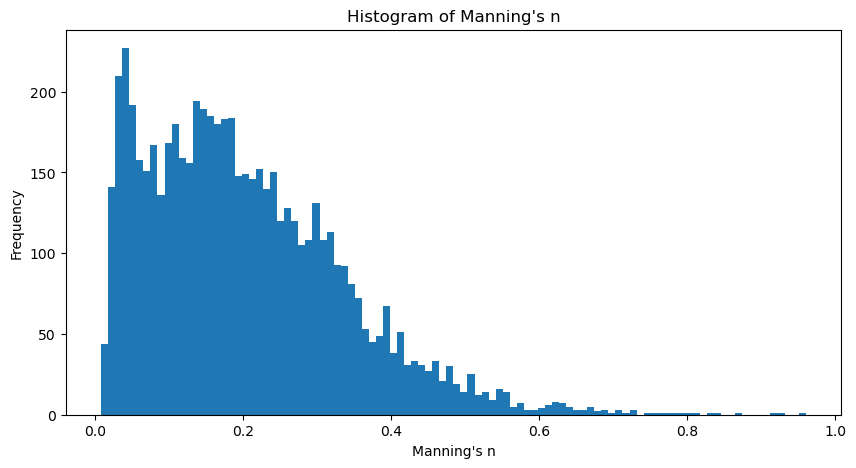

In [11]:
# Plot histogram of Manning's n
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gdf_rivers['reach_manning'], bins=100)
ax.set_title('Histogram of Manning\'s n')
ax.set_xlabel('Manning\'s n')
ax.set_ylabel('Frequency')
plt.show()


In [12]:
# Note: For the Method 2, most of the values are above the 0.15 which is the maximum value presented by Chow 1959 for natural river channels and seems unrealistic. Use with caution.
# Since that this is a large range of manning values, we group them to have handable set of manning classes.
classes_manning=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
gdf_rivers['reach_manning_classes'] = gdf_rivers['reach_manning']
for i in range(0, len(classes_manning)-1):
    gdf_rivers.loc[(gdf_rivers['reach_manning'] >= classes_manning[i]) & (gdf_rivers['reach_manning'] < classes_manning[i+1]), 'reach_manning_classes'] = classes_manning[i+1]
# Define max manning value
gdf_rivers.loc[gdf_rivers['reach_manning'] >= classes_manning[-1], 'reach_manning_classes'] = classes_manning[-1]
# Replace nan values
gdf_rivers['reach_manning_classes'] = gdf_rivers['reach_manning_classes'].fillna(0.05)
# Define a column related to an ID class
gdf_rivers['reach_manning_classes_ID'] = 0
for i in range(0, len(classes_manning)):
    gdf_rivers.loc[gdf_rivers['reach_manning_classes'] == classes_manning[i], 'reach_manning_classes_ID'] = len(classes_manning)-i

table_manning_reach = pd.DataFrame({'reach_manning_classes_ID':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'reach_manning_classes':np.flip(classes_manning[1:])})

Get river width from McManamay et al., 2019

In [13]:
# Calculate the river width using River width area (SWA [m2]) and river length (RL [km]])
df_river_widths['RiverWidth[m]'] = df_river_widths['SWA']/(df_river_widths['RL']*1000)
# Set the minimum river width as 10 m [DEM resolution].
min_width = 10 # [m]
df_river_widths['RiverWidth[m]'][df_river_widths['RiverWidth[m]']<min_width] = min_width
# Join atributes to river shapefile
# Join the shapefile with the CSV table using a common ID
gdf_rivers = gdf_rivers.merge(df_river_widths, on='COMID')


/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_44418/141290731.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_river_widths['RiverWidth[m]'][df_river_widths['RiverWidth[m]']<min_width] = min_width


In [14]:
# Do buffer. Note that the crs must be projected to a system with x and y in [m]
gdf_buffer = gdf_rivers.copy()
gdf_buffer['geometry'] = gdf_buffer.geometry.buffer(gdf_buffer['RiverWidth[m]']/2)
# # Dissolve all features 
# gdf_buffer['dissolve'] = 1
# gdf_buffer= gdf_buffer.dissolve(by='dissolve')



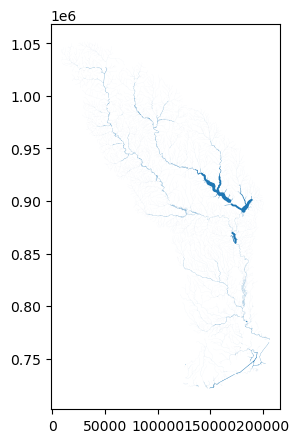

In [15]:
# Plot gdf_buffer
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
gdf_buffer.plot(ax=ax)
plt.show()

# export file to shapefile 
# gdf_buffer.to_file('/Users/gpq/ORNL/Projects/ATS_runs/global_data/hydrography/river_widths/Village/Village_river_widths.shp', driver='ESRI Shapefile')

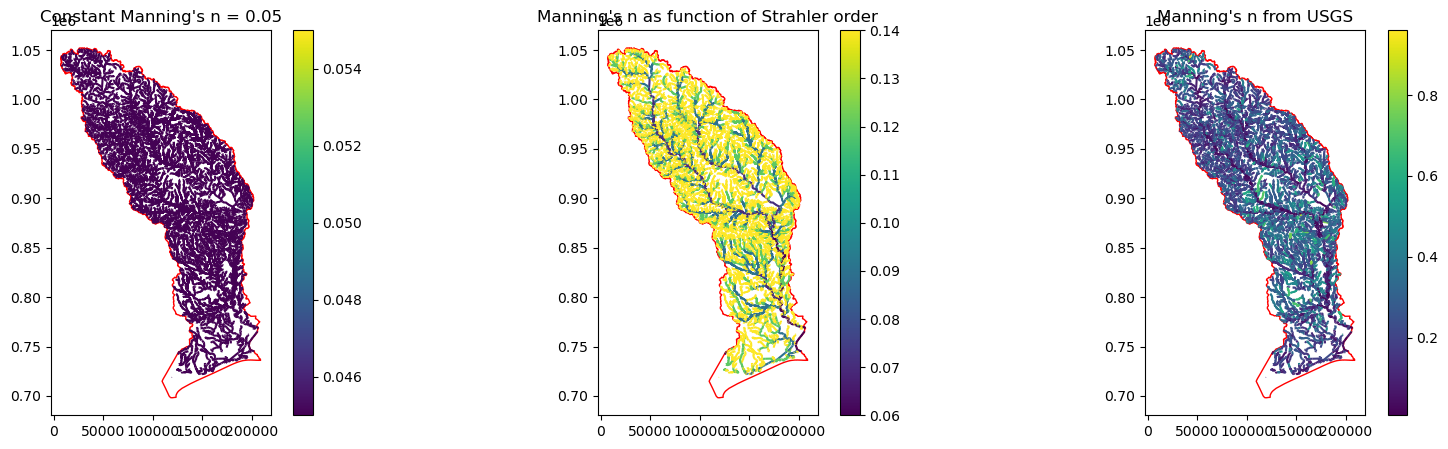

In [16]:
# Make a figure showing the manning coefficient for each river link
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
gdf_rivers.plot(ax=ax[0], column='cte_manning', cmap='viridis', legend=True)
gdf.plot(ax=ax[0], edgecolor='red', facecolor='none')
ax[0].set_title('Constant Manning\'s n = 0.05')

gdf_rivers.plot(ax=ax[1], column='order_manning', cmap='viridis', legend=True)
gdf.plot(ax=ax[1], edgecolor='red', facecolor='none')
ax[1].set_title('Manning\'s n as function of Strahler order')

# gdf_rivers.plot(ax=ax[2],  column='reach_manning_classes_ID', cmap='viridis', legend=True)
gdf_rivers.plot(ax=ax[2],  column='reach_manning', cmap='viridis', legend=True)
gdf.plot(ax=ax[2], edgecolor='red', facecolor='none')
ax[2].set_title('Manning\'s n from USGS')

plt.show()

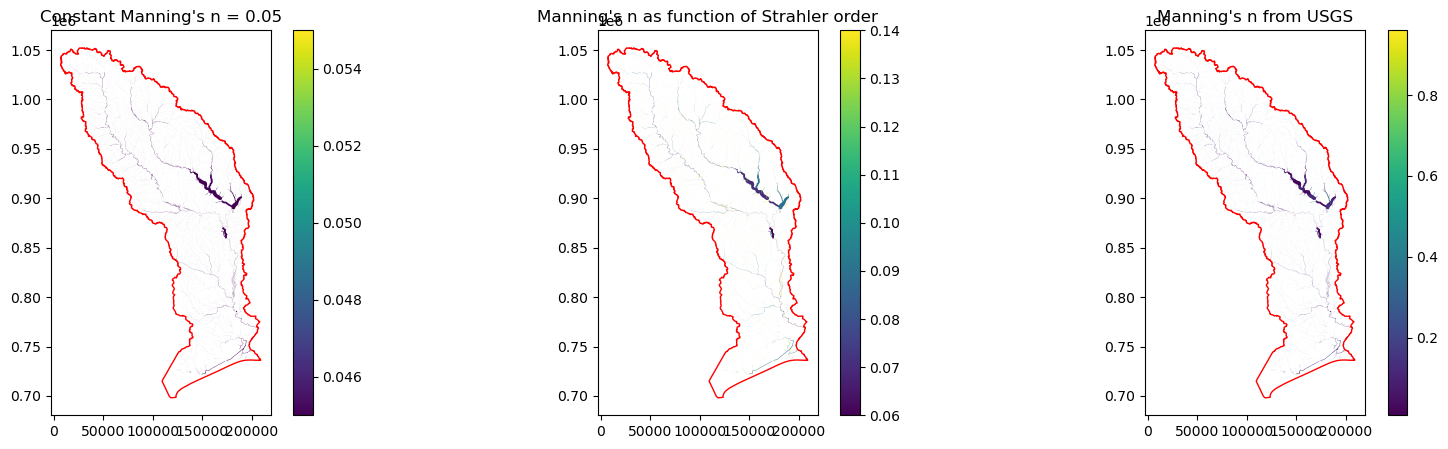

In [17]:
# Make same plot but using river widths as polygons
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
gdf_buffer.plot(ax=ax[0], column='cte_manning', cmap='viridis', legend=True)
gdf.plot(ax=ax[0], edgecolor='red', facecolor='none')
ax[0].set_title('Constant Manning\'s n = 0.05')

gdf_buffer.plot(ax=ax[1], column='order_manning', cmap='viridis', legend=True)
gdf.plot(ax=ax[1], edgecolor='red', facecolor='none')
ax[1].set_title('Manning\'s n as function of Strahler order')

gdf_buffer.plot(ax=ax[2],  column='reach_manning', cmap='viridis', legend=True)
gdf.plot(ax=ax[2], edgecolor='red', facecolor='none')
ax[2].set_title('Manning\'s n from USGS')

plt.show()



Clip NLCD data with watershed boundary


In [18]:
# Define box to clip data and leave a buffer of 1000 m for the edges
buffer_box = 1500 # [m]. # 1000 This assumes that the x,y coordinates is in meters
# Define box to clip
geom= box(np.array(gdf.bounds.minx)-buffer_box, np.array(gdf.bounds.miny)-buffer_box, np.array(gdf.bounds.maxx)+buffer_box, np.array(gdf.bounds.maxy)+buffer_box)
# Create a geodataframe for the box
geo = gpd.GeoDataFrame({'geometry': geom}, index=[0], crs=src.crs)
# Get the coordinates in GeoJson format
def getFeatures(gdf):
    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
    import json
    return [json.loads(gdf.to_json())['features'][0]['geometry']]
coords = getFeatures(geo)

# Clip data
out_image, out_transform = mask(src, coords, crop=True)
# out_image, out_transform = mask(dataset=src, shapes=gdf.geometry.apply(mapping), crop=True) # This option is for using the watershed boundary and not a box

# Save raster
meta.update({"driver": "GTiff",
             "height": out_image.shape[1],
             "width": out_image.shape[2],
             "transform": out_transform})

with rasterio.open(f"{path_output}/clipped_nlcd.tif", "w", **meta) as dest:
    dest.write(out_image)
# Load clipped raster
nlcd_file_clip = f"{path_output}/clipped_nlcd.tif"
src_clip = rasterio.open(nlcd_file_clip)

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_44418/785795281.py:11: UserWarning: GeoDataFrame's CRS is not representable in URN OGC format. Resulting JSON will contain no CRS information.
  return [json.loads(gdf.to_json())['features'][0]['geometry']]


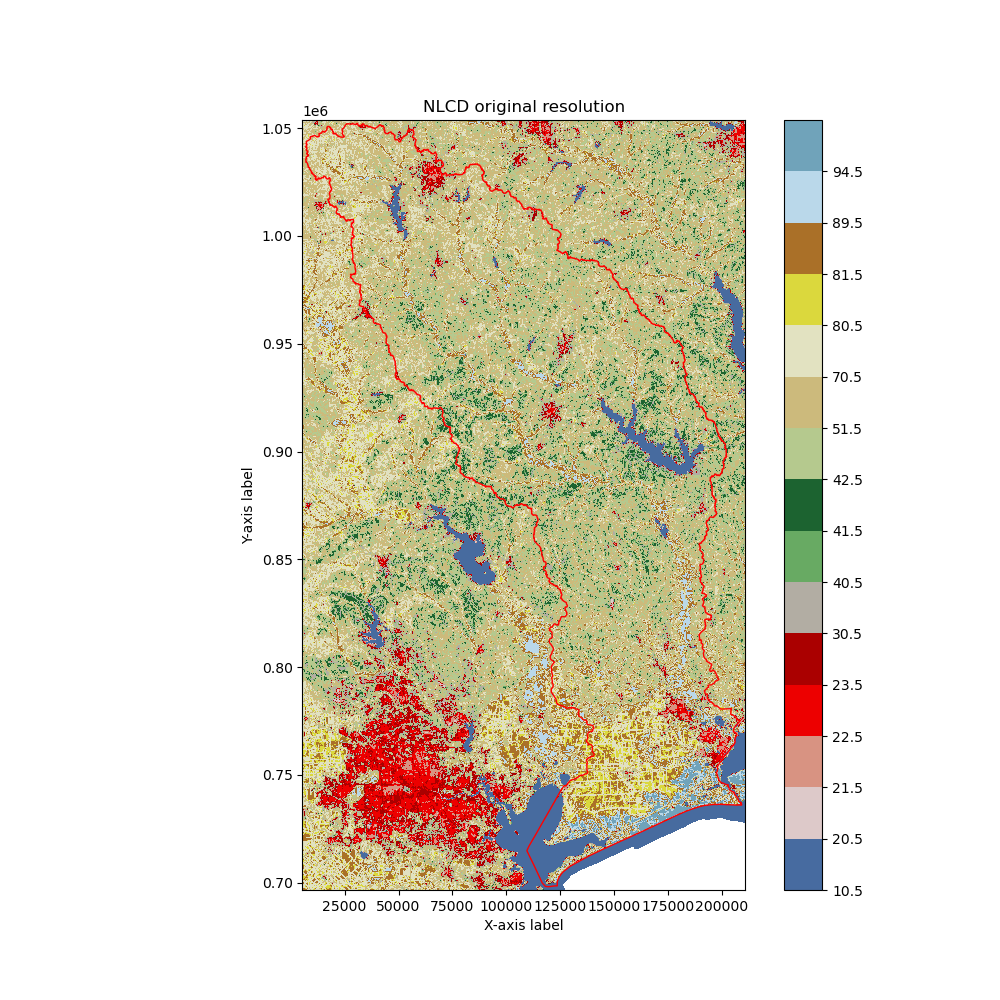

In [19]:
import ipympl
# Set NaN values when cell is equal to zero
df_out_image=pd.DataFrame(out_image[0,:,:])
df_out_image[df_out_image == 0] = np.nan

# get the NLCD Classess and colormap which uses official NLCD colors and labels
Classes_NLCD = np.unique(df_out_image.to_numpy().flatten())
Classes_NLCD = Classes_NLCD[~np.isnan(Classes_NLCD)]
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
                watershed_workflow.colors.generate_nlcd_colormap(Classes_NLCD)

# Plot the NLCD map for the watershed domain
# Define right extent for plotting
extents = [src_clip.bounds.left, src_clip.bounds.right, src_clip.bounds.bottom, src_clip.bounds.top]
fig, ax = plt.subplots(1, 1)
# cmap = plt.cm.get_cmap('tab10', Classes_NLCD.size)
fig.set_size_inches(10, 10)
mp = plt.imshow(df_out_image, norm=nlcd_norm, cmap=nlcd_cmap, extent=extents, origin='upper')

# Set the title and axis labels
ax.set_title('NLCD original resolution')
ax.set_xlabel('X-axis label')
ax.set_ylabel('Y-axis label')
cb = fig.colorbar(mp , orientation='vertical')
cb.set_ticks(nlcd_ticks[0:len(nlcd_ticks)-1])
# cb.ax.set_yticklabels(nlcd_labels)

gdf.plot(ax=ax, edgecolor='red', facecolor='none')

plt.show()

Resample NLCD to 10m x 10m in order to capture small channels

In [20]:
# Define the target resolution and the resampling method
dst_res = (10, 10)  # target resolution in the target CRS
resampling = Resampling.nearest  # resampling method

# Define the output file
dst = f'{path_output}/clipped_nlcd_resampled.tif'

# Compute the new dimensions of the resampled raster
transform, width, height = rasterio.warp.calculate_default_transform(
    src_clip.crs, src_clip.crs, src_clip.width, src_clip.height, *src_clip.bounds, resolution=dst_res)

# Define the output raster profile
profile = src_clip.profile
profile.update({
    'crs': src.crs,
    'transform': transform,
    'width': width,
    'height': height
})

# Open the destination raster for writing
with rasterio.open(dst, 'w', **profile) as dst_dataset:

    # Resample the source raster to the target resolution
    rasterio.warp.reproject(
        source=rasterio.band(src_clip, 1),
        destination=rasterio.band(dst_dataset, 1),
        src_transform=src_clip.transform,
        src_crs=src_clip.crs,
        dst_transform=transform,
        dst_crs=src_clip.crs,
        resampling=resampling
    )

    # Close the destination dataset
    dst_dataset.close()


In [21]:
# Set the path to the input shapefile in GeoPandas format
# input_shapefile = "path/to/input.shp"

# Set the name of the attribute to use for the conversion
if method_manning_channels == 1:
    gdf_buffer['constant_ID'] = 1
    attribute_name = "constant_ID"
elif method_manning_channels == 2:
    attribute_name = "Order"
elif method_manning_channels == 3:
    attribute_name = "reach_manning_classes_ID"
else:
    print("Method not defined")

# Set the path to the output raster
output_raster = f'{path_output}/manning_network.tif'

# Open the reference raster
with rasterio.open(dst) as src:
    transform = src.transform
    crs = src.crs
    width = src.width
    height = src.height
    dtype = src.dtypes[0]
    nodata = src.nodata
    
# Create a new image array with the same shape as the reference raster
out_image = np.zeros((height, width), dtype=dtype)

# Burn the attribute values into the image array
shapes = ((geom, value) for geom, value in zip(gdf_buffer.geometry, gdf_buffer[attribute_name]))
out_image = rasterize(shapes, out_shape=out_image.shape, transform=transform, fill=0, all_touched=True, dtype=dtype)

# Write the output raster to disk
with rasterio.open(output_raster, "w", driver="GTiff", width=width, height=height, count=1, dtype=dtype, nodata=nodata, transform=transform, crs=crs) as dst:
    dst.write(out_image, 1)


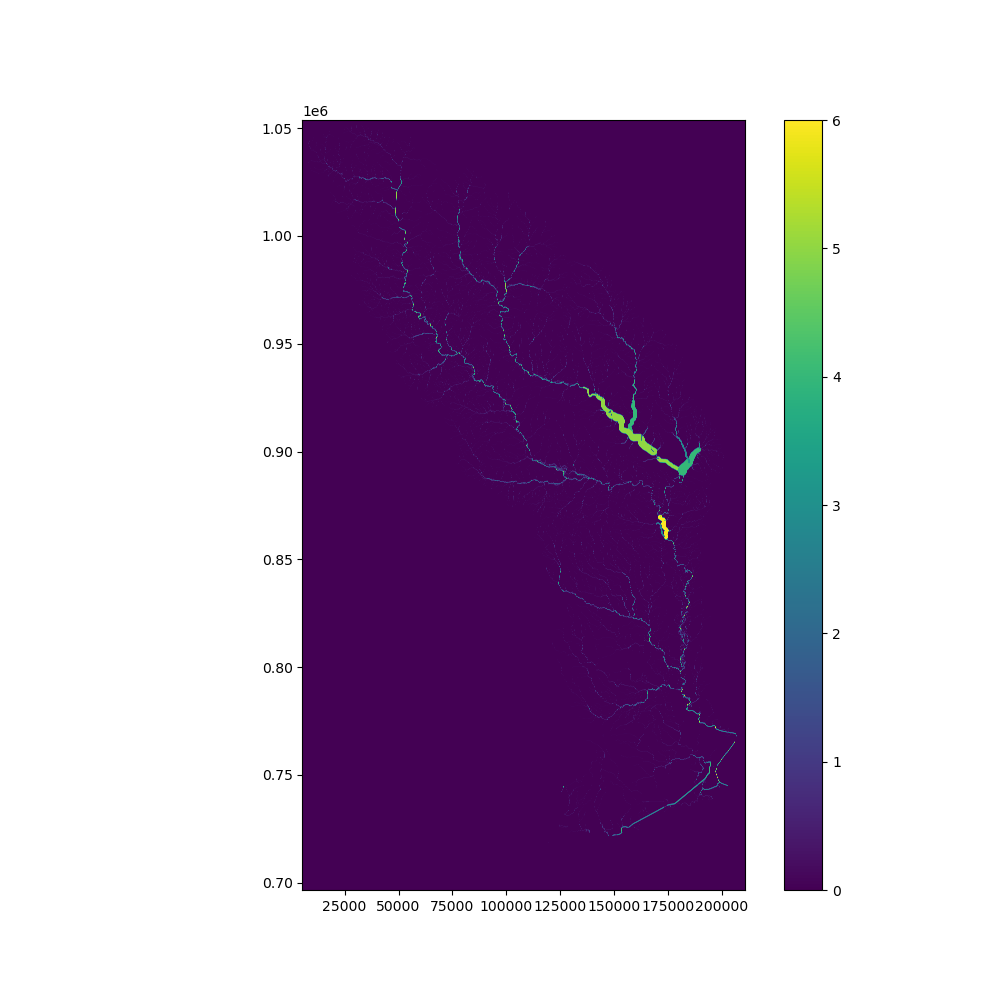

In [22]:
# Check plot of the rasterized version of river network
extents = [src_clip.bounds.left, src_clip.bounds.right, src_clip.bounds.bottom, src_clip.bounds.top]
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)
mp = plt.imshow(out_image, extent=extents, origin='upper')
cb = fig.colorbar(mp , orientation='vertical')
plt.show()

In [23]:
Classes_NLCD

array([11., 21., 22., 23., 24., 31., 41., 42., 43., 52., 71., 81., 82.,
       90., 95.])

In [24]:
dst = f'{path_output}/clipped_nlcd_resampled.tif'
# Read NLCD data to be merged with manning's data in network

with rasterio.open(dst) as src:
    out_meta = src.meta.copy()
    out_arr = src.read(1)

# A new dictionary of mannings values is created with the NLCD values/ We used the IDs from 60 to 70 for Manning's ID, sine that NLCD labels do not include this range
# see https://www.mrlc.gov/data/legends/national-land-cover-database-class-legend-and-description
# This has the limitation that only 11 manning classes can be used. If more classes are needed, the NLCD IDs should be changed

Classes_NLCD = np.unique(out_image)
# Drop zero value
Classes_NLCD = Classes_NLCD[Classes_NLCD!=0]

df_nlcd_manning = out_arr.copy()
for i in Classes_NLCD:
    Classes_NLCD_manning = 59+ i
    df_nlcd_manning[out_image == i] = Classes_NLCD_manning
    if i >= 11:
        error = "Number of Manning's classes is open channels is greater than 11, and duplicate labels are likely to occur"

#  Set nan 
df_nlcd_manning=pd.DataFrame(df_nlcd_manning)
df_nlcd_manning[df_nlcd_manning == 0] = np.nan




In [20]:
# # The class "Perennial Ice/Snow" will be replaced by "Open Water - River Channel". Then first check that "Perennial Ice/Snow" is not in the map
# # Check that "12" is not in Classes_NLCD
# # Note: This is done to use the function watershed_workflow.colors.generate_nlcd_colormap. Ideally, "Open Water - River Channel" 
# # should be assigned to a new class value e.g. 15
# Classes_NLCD

# # Merge two raster to create a new class Open Water - River Channel with value "12"
# df_nlcd_manning = out_arr.copy()
# df_nlcd_manning[out_image == 1] = 12
# #  Set nan 
# df_nlcd_manning=pd.DataFrame(df_nlcd_manning)
# df_nlcd_manning[df_nlcd_manning == 0] = np.nan

In [25]:
Classes_NLCD_new = np.unique(np.array(df_nlcd_manning).flatten())
Classes_NLCD_new = Classes_NLCD_new[~np.isnan(Classes_NLCD_new)]
Classes_NLCD_new 

array([11., 21., 22., 23., 24., 31., 41., 42., 43., 52., 60., 61., 62.,
       63., 64., 65., 71., 81., 82., 90., 95.])

In [22]:
# Do final figure showing the new class
# Create a figure and axis object
# -- get the NLCD colormap which uses official NLCD colors and labels
# Classes_NLCD_new = np.unique(np.array(df_nlcd_manning).flatten())
# Classes_NLCD_new = Classes_NLCD_new[~np.isnan(Classes_NLCD_new)]
# nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
#                 watershed_workflow.colors.generate_nlcd_colormap(Classes_NLCD_new)

# Change label name for the new classs
# nlcd_labels[1] = 'Open Water - River Channel'

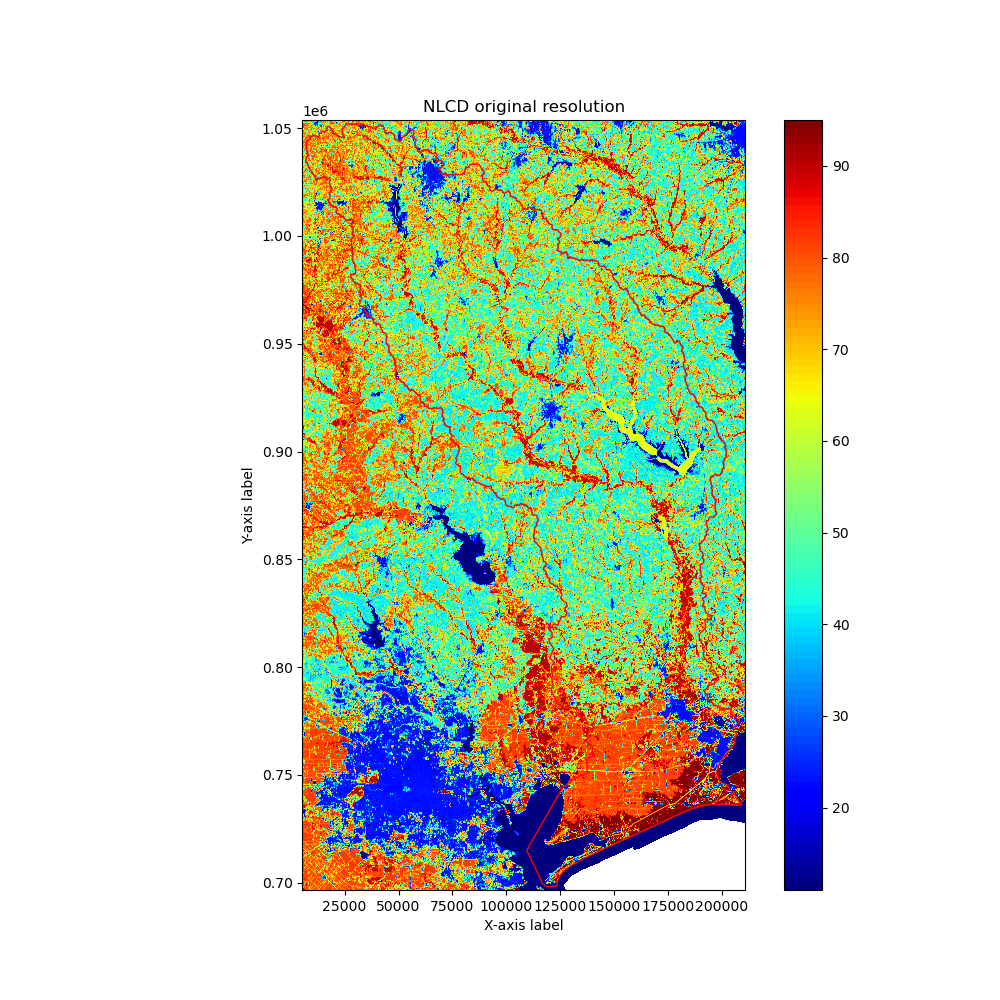

In [26]:
# Plot the raster image on the axis
# Define right extent for plotting
extents = [src_clip.bounds.left, src_clip.bounds.right, src_clip.bounds.bottom, src_clip.bounds.top]
fig, ax = plt.subplots(1, 1)
# cmap = plt.cm.get_cmap('tab10', Classes_NLCD.size)
cmap = plt.cm.get_cmap('jet', 100)
fig.set_size_inches(10, 10)
# mp = plt.imshow(df_nlcd_manning, norm=nlcd_norm, cmap=nlcd_cmap, extent=extents, origin='upper')
mp = plt.imshow(df_nlcd_manning, cmap=cmap, extent=extents, origin='upper')

# Set the title and axis labels
ax.set_title('NLCD original resolution')
ax.set_xlabel('X-axis label')
ax.set_ylabel('Y-axis label')
cb = fig.colorbar(mp , orientation='vertical')
# cb.set_ticks(nlcd_ticks)
# cb.ax.set_yticklabels(nlcd_labels)
gdf.plot(ax=ax, edgecolor='red', facecolor='none')

plt.show()

In [27]:
# Save raster
out_meta.update({"driver": "GTiff",
                 "height": out_arr.shape[0],
                 "width": out_arr.shape[1],
                 "transform": out_meta['transform'],
                 "crs": out_meta['crs'],
                 "nodata": 0})
f'{path_output}/clipped_nlcd_resampled.tif'
with rasterio.open(f'{path_output}/nlcd_channel.tif', "w", **out_meta) as dest:
    dest.write(np.reshape(np.array(df_nlcd_manning), (1, out_arr.shape[0], out_arr.shape[1])))

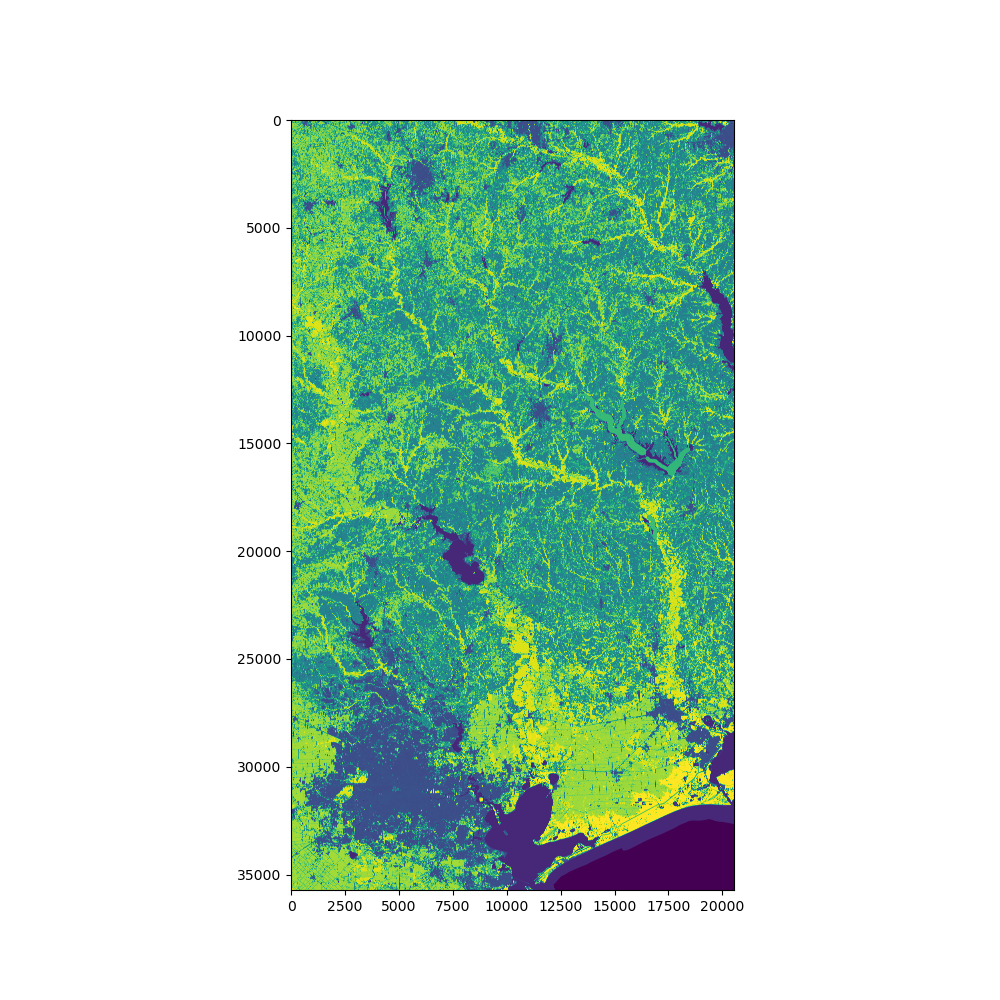

In [28]:
# Check final results

# Load clipped raster
nlcd_manning_file = f'{path_output}/nlcd_channel.tif'
src_manning = rasterio.open(nlcd_manning_file)

nlcd_manning_test = src_manning.read()

fig, ax = plt.subplots(1, 1)
# cmap = plt.cm.get_cmap('tab10', Classes_NLCD.size)
fig.set_size_inches(10, 10)
mp = plt.imshow(nlcd_manning_test[0,:,:])

plt.show()

# Done!!!

In [29]:
# Transform from NLCD values to manning values
# Define Manning for each NLCD class.  See https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/developing-a-terrain-model-and-geospatial-layers/creating-land-cover-mannings-n-values-and-impervious-layers

# Note: For Perennial Ice/Snow, Lichens and Moss there are not values (Set 0.1 for now)
NLCD_Manning_values = {
    'Open Water' : [11, 0.0375, 0.025, 0.05], 
    'Perennial Ice/Snow' : [12, 0.1, 0.1, 0.1], 
    'Developed, Open Space' : [21, 0.04, 0.03, 0.05],
    'Developed, Low Intensity' : [22, 0.09, 0.06, 0.12],
    'Developed, Medium Intensity' : [23, 0.12, 0.08, 0.16],
    'Developed, High Intensity' : [24, 0.16, 0.12, 0.20],
    'Barren Land' : [31, 0.0265, 0.023, 0.030],
    'Deciduous Forest' : [41, 0.15, 0.10, 0.20],
    'Evergreen Forest' : [42, 0.12, 0.08, 0.16],
    'Mixed Forest' : [43, 0.14, 0.08, 0.20],
    'Dwarf Scrub' : [51, 0.0375, 0.025, 0.05],   
    'Shrub/Scrub' : [52, 0.115, 0.07, 0.16],
    'Grassland/Herbaceous' : [71, 0.0375, 0.025, 0.05],
    'Sedge/Herbaceous' : [72, 0.0375, 0.025, 0.05],
    'Lichens'  : [73, 0.1, 0.1, 0.1],
    'Moss'   : [74, 0.1, 0.1, 0.1],
    'Pasture/Hay' : [81, 0.0375, 0.025, 0.05],
    'Cultivated Crops' : [82, 0.035, 0.020, 0.05],
    'Woody Wetlands' : [90, 0.0975, 0.045, 0.15],
    'Emergent Herbaceous Wetlands' : [95, 0.0675, 0.05, 0.085],
   
}

# # Create the classes for Manning
# unique_Manning_NLCD = np.unique(df_nlcd_manning[(df_nlcd_manning>=60) & (df_nlcd_manning<=70)])
# # remove nan values
# unique_Manning_NLCD = unique_Manning_NLCD[~np.isnan(unique_Manning_NLCD)]


for key in np.unique(Classes_NLCD):
    if method_manning_channels == 1:
        NLCD_Manning_values[f'Open Channel Class 1'] = [60, cte_manning, cte_manning, cte_manning]
    elif method_manning_channels == 2:
        NLCD_Manning_values[f'Open Channel Class {key}'] = [key+59, table_manning[table_manning['Order']==key]['order_manning'].values[0], table_manning[table_manning['Order']==key]['order_manning'].values[0], table_manning[table_manning['Order']==key]['order_manning'].values[0]]
    elif method_manning_channels == 3:
        NLCD_Manning_values[f'Open Channel Class {key}'] = [key+59, table_manning_reach[table_manning_reach['reach_manning_classes_ID']==key]['reach_manning_classes'].values[0], table_manning_reach[table_manning_reach['reach_manning_classes_ID']==key]['reach_manning_classes'].values[0], table_manning_reach[table_manning_reach['reach_manning_classes_ID']==key]['reach_manning_classes'].values[0]]

    
# Create the dataframe
NLCD_Manning_values = pd.DataFrame(data=NLCD_Manning_values, index=['NLCD value', 'n_mean', 'n_min', 'n_max'])
# Save the dataframe
NLCD_Manning_values.to_csv(f'{path_output}/NLCD_Manning_values.csv')
NLCD_Manning_values


,Open Water,Perennial Ice/Snow,"Developed, Open Space","Developed, Low Intensity","Developed, Medium Intensity","Developed, High Intensity",Barren Land,Deciduous Forest,Evergreen Forest,Mixed Forest,...,Pasture/Hay,Cultivated Crops,Woody Wetlands,Emergent Herbaceous Wetlands,Open Channel Class 1,Open Channel Class 2,Open Channel Class 3,Open Channel Class 4,Open Channel Class 5,Open Channel Class 6
NLCD value,11.0000,12.0,21.00,22.00,23.00,24.00,31.0000,41.00,42.00,43.00,...,81.0000,82.000,90.0000,95.0000,60.00,61.00,62.00,63.00,64.00,65.00
n_mean,0.0375,0.1,0.04,0.09,0.12,0.16,0.0265,0.15,0.12,0.14,...,0.0375,0.035,0.0975,0.0675,0.14,0.12,0.09,0.09,0.07,0.06
n_min,0.0250,0.1,0.03,0.06,0.08,0.12,0.0230,0.10,0.08,0.08,...,0.0250,0.020,0.0450,0.0500,0.14,0.12,0.09,0.09,0.07,0.06
n_max,0.0500,0.1,0.05,0.12,0.16,0.20,0.0300,0.20,0.16,0.20,...,0.0500,0.050,0.1500,0.0850,0.14,0.12,0.09,0.09,0.07,0.06


In [30]:
# Reclasify nlcd with manning values
df_manning = df_nlcd_manning.copy()

for key_NLCD in NLCD_Manning_values.head():
    print(key_NLCD)
    df_manning[df_nlcd_manning == NLCD_Manning_values.loc['NLCD value'][key_NLCD]] = NLCD_Manning_values.loc['n_mean'][key_NLCD]


Open Water
Perennial Ice/Snow
Developed, Open Space
Developed, Low Intensity
Developed, Medium Intensity
Developed, High Intensity
Barren Land
Deciduous Forest
Evergreen Forest
Mixed Forest
Dwarf Scrub
Shrub/Scrub
Grassland/Herbaceous
Sedge/Herbaceous
Lichens
Moss
Pasture/Hay
Cultivated Crops
Woody Wetlands
Emergent Herbaceous Wetlands
Open Channel Class 1
Open Channel Class 2
Open Channel Class 3
Open Channel Class 4
Open Channel Class 5
Open Channel Class 6


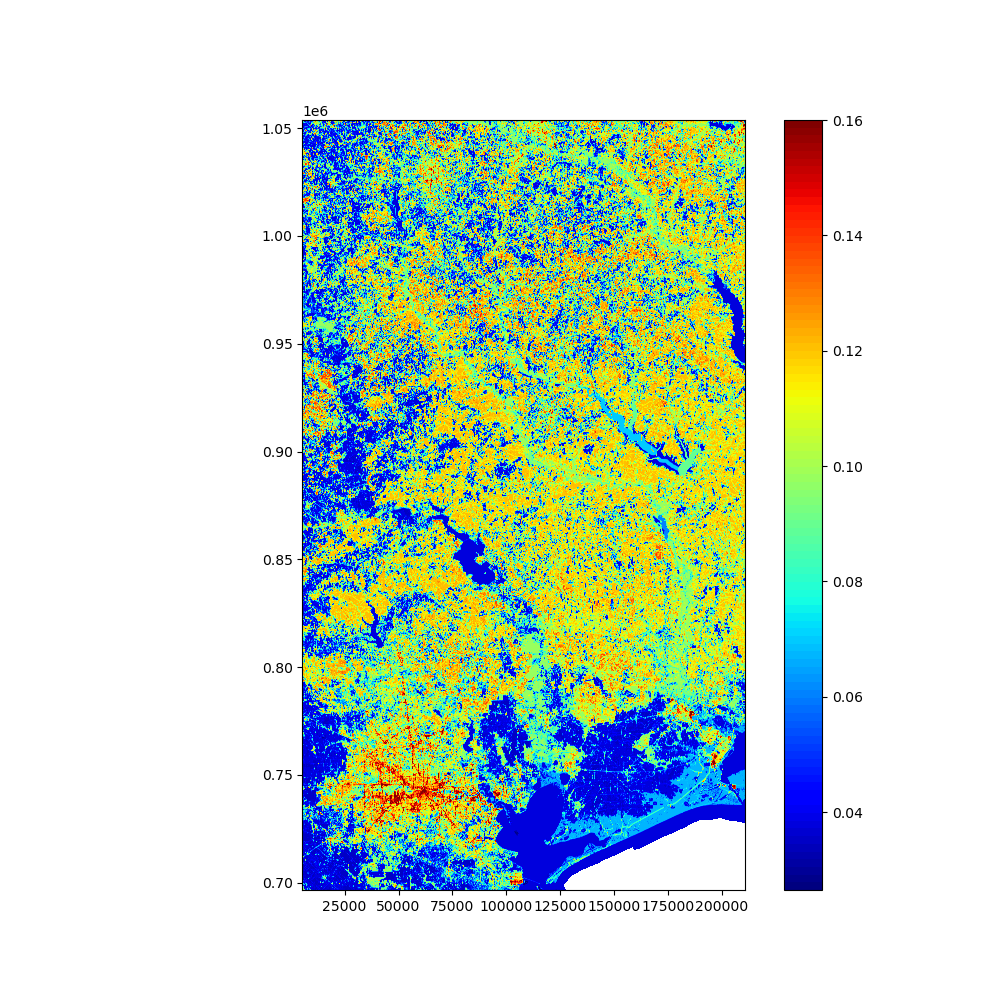

array([0.0265, 0.035 , 0.0375, 0.04  , 0.06  , 0.0675, 0.07  , 0.09  ,
       0.0975, 0.115 , 0.12  , 0.14  , 0.15  , 0.16  ,    nan])

In [31]:
# Plot the results
fig, ax = plt.subplots(1, 1)
cmap = plt.cm.get_cmap('jet', 100)
fig.set_size_inches(10, 10)
mp = plt.imshow(df_manning, cmap=cmap, extent=extents, origin='upper')
plt.colorbar(mp)
plt.show()

# get unique values
np.unique(df_manning)

In [32]:
# Save raster
out_meta.update({"driver": "GTiff",
                 "height": out_arr.shape[0],
                 "width": out_arr.shape[1],
                 "transform": out_meta['transform'],
                 "crs": out_meta['crs'],
                 'dtype': 'float32',
                 "nodata": 0})

with rasterio.open( f'{path_output}/manning_values.tif', "w", **out_meta) as dest:
    dest.write(np.reshape(np.array(df_manning), (1, out_arr.shape[0], out_arr.shape[1])))

In [33]:
# Load clipped raster for reference
nlcd_file_clip = f"{path_output}/clipped_nlcd.tif" # 30 x 30 m
src_clip = rasterio.open(nlcd_file_clip)

# Set the path to the output raster
output_raster = f'{path_output}/channel_classes.tif'

# Open the reference raster
with rasterio.open(nlcd_file_clip) as src:
    transform = src.transform
    crs = src.crs
    width = src.width
    height = src.height
    dtype = src.dtypes[0]
    nodata = src.nodata
    
# Create a new image array with the same shape as the reference raster
out_image = np.zeros((height, width), dtype=dtype)

# Burn the attribute values into the image array
shapes = ((geom, value) for geom, value in zip(gdf_buffer.geometry, gdf_buffer[attribute_name]))
out_image = rasterize(shapes, out_shape=out_image.shape, transform=transform, fill=0, all_touched=True, dtype=dtype)


Classes_NLCD = np.unique(out_image)
# Drop zero value
Classes_NLCD = Classes_NLCD[Classes_NLCD!=0]

for i in Classes_NLCD:
    Classes_NLCD_manning = 59+ i
    out_image[out_image == i] = Classes_NLCD_manning
    if i >= 11:
        error = "Number of Manning's classes is open channels is greater than 11, and duplicate labels are likely to occur"

# Write the output raster to disk
with rasterio.open(output_raster, "w", driver="GTiff", width=width, height=height, count=1, dtype=dtype, nodata=nodata, transform=transform, crs=crs) as dst:
    dst.write(out_image, 1)
